# Logistic Regression from Airam 

**Split:** 64 / 16 / 20 (4,364 train / 1,091 val / 1,364 test)  
**Class balance:** 3.23% bankrupt — handled via `class_weight='balanced'`  
**Primary metrics:** Recall and PR-AUC

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)

DATA_DIR = Path('../data/airam-data')
RANDOM_STATE = 42

## 1. Load Data

In [58]:
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_val   = pd.read_csv(DATA_DIR / 'X_val.csv')
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | bankrupt={y_train.mean()*100:.2f}%')
print(f'Val:   {X_val.shape}   | bankrupt={y_val.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}  | bankrupt={y_test.mean()*100:.2f}%')

Train: (4364, 106) | bankrupt=3.23%
Val:   (1091, 106)   | bankrupt=3.21%
Test:  (1364, 106)  | bankrupt=3.23%


## 2. StandardScaler

In [59]:
scaler = StandardScaler()

X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f'After scaling: train={X_train_sc.shape}, val={X_val_sc.shape}, test={X_test_sc.shape}')

After scaling: train=(4364, 106), val=(1091, 106), test=(1364, 106)


## 3. Train

In [60]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train_sc, y_train)
print('Training complete.')

Training complete.


## 4. Threshold Tuning on Val

Best threshold (max G-Mean on val): 0.3266
  Val G-Mean=0.8556 | TPR=0.8286 | FPR=0.1165
F1-threshold reference: 0.9776 | Val F1=0.4746


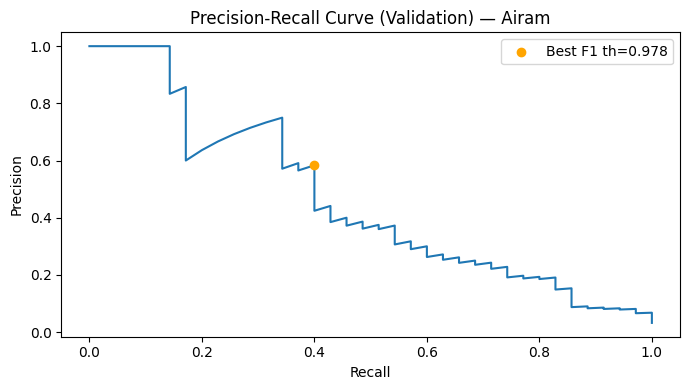

In [ ]:
y_val_prob = model.predict_proba(X_val_sc)[:, 1]

# F1-based threshold on PR curve (kept for reference)
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_val, y_val_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
best_idx_f1 = np.argmax(f1_arr[:-1])
best_th_f1 = thresholds_pr[best_idx_f1]

# G-Mean threshold on ROC curve (used for evaluation)
fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_prob)
gmean_arr = np.sqrt(tpr * (1 - fpr))
best_idx_gmean = np.argmax(gmean_arr)
best_th_gmean = thresholds_roc[best_idx_gmean]

# Use G-Mean threshold downstream
best_th = best_th_gmean

print(f'Best threshold (max G-Mean on val): {best_th_gmean:.4f}')
print(f'  Val G-Mean={gmean_arr[best_idx_gmean]:.4f} | TPR={tpr[best_idx_gmean]:.4f} | FPR={fpr[best_idx_gmean]:.4f}')
print(f'F1-threshold reference: {best_th_f1:.4f} | Val F1={f1_arr[best_idx_f1]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(recall_arr, precision_arr)
plt.scatter(recall_arr[best_idx_f1], precision_arr[best_idx_f1], color='orange', zorder=5, label=f'Best F1 th={best_th_f1:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation) — v3')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate Test Set

In [62]:
y_test_prob = model.predict_proba(X_test_sc)[:, 1]
y_test_pred = (y_test_prob >= best_th).astype(int)

auc    = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)
f1     = f1_score(y_test, y_test_pred)
rec    = recall_score(y_test, y_test_pred)
prec   = precision_score(y_test, y_test_pred)

print('=== Test Results — Logistic Regression (Airam) ===')
print(f'AUC:       {auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1:        {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Threshold (G-Mean val): {best_th:.4f}')
print()
print('Confusion Matrix (rows=actual, cols=predicted):')
print(confusion_matrix(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred, target_names=['Solvent', 'Bankrupt']))

=== Test Results — Logistic Regression (Airam) ===
AUC:       0.9476
PR-AUC:    0.5087
Recall:    0.9091
F1:        0.3404
Precision: 0.2094
Threshold (G-Mean val): 0.3266

Confusion Matrix (rows=actual, cols=predicted):
[[1169  151]
 [   4   40]]

              precision    recall  f1-score   support

     Solvent       1.00      0.89      0.94      1320
    Bankrupt       0.21      0.91      0.34        44

    accuracy                           0.89      1364
   macro avg       0.60      0.90      0.64      1364
weighted avg       0.97      0.89      0.92      1364



## 6. Top Coefficients (Feature Importance)

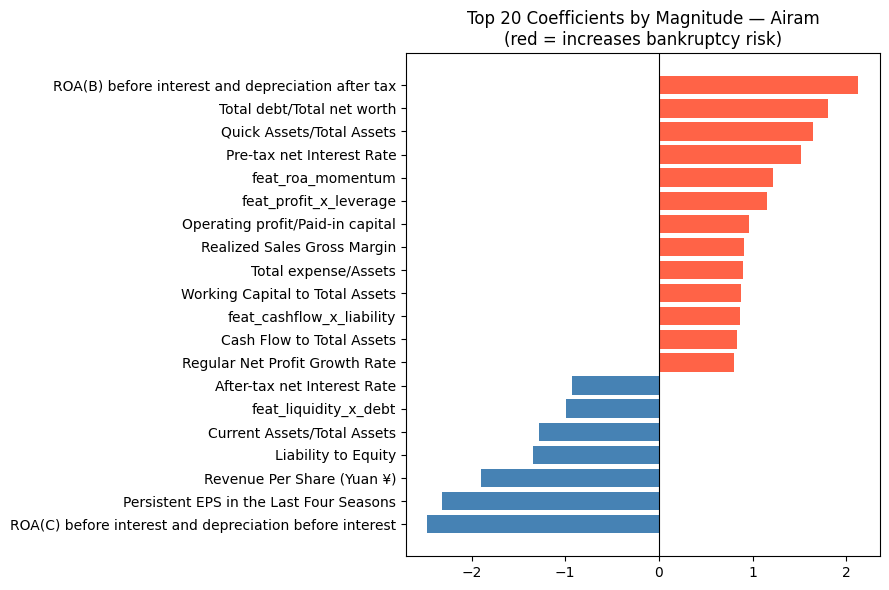


Top 20 features by coefficient magnitude:
                                                feature  coefficient
ROA(C) before interest and depreciation before interest    -2.471939
                Persistent EPS in the Last Four Seasons    -2.315035
      ROA(B) before interest and depreciation after tax     2.130662
                             Revenue Per Share (Yuan ¥)    -1.897737
                             Total debt/Total net worth     1.804512
                              Quick Assets/Total Assets     1.645084
                              Pre-tax net Interest Rate     1.522347
                                    Liability to Equity    -1.345780
                            Current Assets/Total Assets    -1.276273
                                      feat_roa_momentum     1.222136
                                 feat_profit_x_leverage     1.152733
                                  feat_liquidity_x_debt    -0.993634
                       Operating profit/Paid-in capital     

In [63]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

top_n = 20
top_df = coef_df.head(top_n).sort_values('coefficient')
colors = ['tomato' if c > 0 else 'steelblue' for c in top_df['coefficient']]

plt.figure(figsize=(9, 6))
plt.barh(top_df['feature'], top_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} Coefficients by Magnitude — Airam\n(red = increases bankruptcy risk)')
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} features by coefficient magnitude:')
print(coef_df.head(top_n)[['feature','coefficient']].to_string(index=False))